In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Check missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [6]:
# Convert date_added to datetime safely
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', format='mixed')

In [7]:
# Extract year and month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [8]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [9]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Convert date_added to datetime safely
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', format='mixed')

# Extract year and month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Clean duration
df['duration_int'] = df['duration'].str.extract(r'(\d+)')
df['duration_int'] = pd.to_numeric(df['duration_int'], errors='coerce')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_int
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,2.0


Movies vs TV Shows

In [10]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


Content added over time

In [11]:
df.groupby('year_added')['title'].count().sort_values(ascending=False)

,title
year_added,
2019.0,2016
2020.0,1879
2018.0,1649
2021.0,1498
2017.0,1188
2016.0,429
2015.0,82
2014.0,24
2011.0,13


Top Genres

In [12]:
df['main_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0])
df['main_genre'].value_counts().head(10)

,count
main_genre,
Dramas,1600
Comedies,1210
Action & Adventure,859
Documentaries,829
International TV Shows,774
Children & Family Movies,605
Crime TV Shows,399
Kids' TV,388
Stand-Up Comedy,334


Top Countries

In [13]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


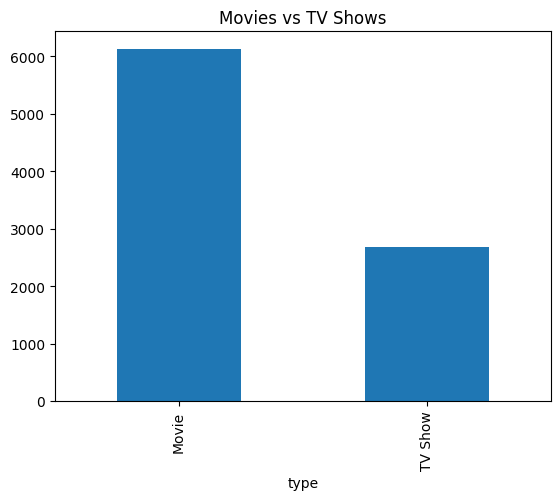

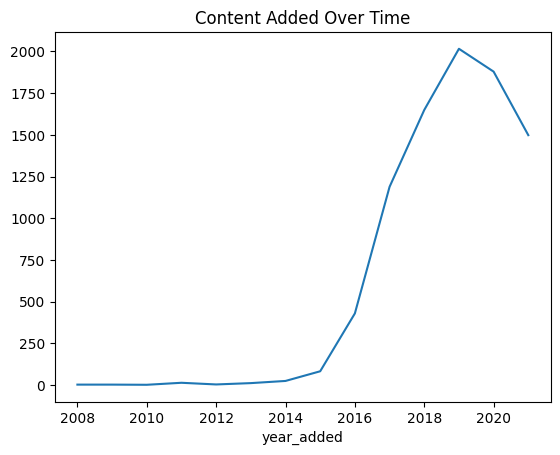

In [14]:
import matplotlib.pyplot as plt

# Movies vs TV
df['type'].value_counts().plot(kind='bar', title='Movies vs TV Shows')
plt.show()

# Content over years
df.groupby('year_added')['title'].count().plot(kind='line', title='Content Added Over Time')
plt.show()

In [15]:
df.to_csv('cleaned_ott_data.csv', index=False)

#SQL

In [17]:
import sqlite3

# Create in-memory database
conn = sqlite3.connect(':memory:')

# Load dataframe into SQL table
df.to_sql('netflix', conn, index=False, if_exists='replace')

8807

In [18]:
query = """
SELECT type, COUNT(*) as count
FROM netflix
GROUP BY type
"""
pd.read_sql(query, conn)

,type,count
0,Movie,6131
1,TV Show,2676


In [19]:
query = """
SELECT country, COUNT(*) as total
FROM netflix
GROUP BY country
ORDER BY total DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,country,total
0,United States,2818
1,India,972
2,Unknown,831
3,United Kingdom,419
4,Japan,245
5,South Korea,199
6,Canada,181
7,Spain,145
8,France,124
9,Mexico,110


In [20]:
query = """
SELECT year_added, COUNT(*) as total
FROM netflix
GROUP BY year_added
ORDER BY year_added
"""
pd.read_sql(query, conn)

,year_added,total
0,NaN,10
1,2008.0,2
2,2009.0,2
3,2010.0,1
4,2011.0,13
5,2012.0,3
6,2013.0,11
7,2014.0,24
8,2015.0,82
9,2016.0,429


In [21]:
query = """
SELECT main_genre, COUNT(*) as total
FROM netflix
GROUP BY main_genre
ORDER BY total DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,main_genre,total
0,Dramas,1600
1,Comedies,1210
2,Action & Adventure,859
3,Documentaries,829
4,International TV Shows,774
5,Children & Family Movies,605
6,Crime TV Shows,399
7,Kids' TV,388
8,Stand-Up Comedy,334
9,Horror Movies,275


### SQL Analysis

Performed SQL-based analysis using SQLite to extract insights from cleaned data.

In [22]:
movies_vs_tv = pd.read_sql("""
SELECT type, COUNT(*) as count FROM netflix GROUP BY type
""", conn)

movies_vs_tv.to_csv('movies_vs_tv.csv', index=False)

In [23]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')
plt.title('Movies vs TV Shows')
plt.savefig('movies_vs_tv.png')
plt.close()